In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler

# K-means
from sklearn.cluster import KMeans

# NLP
from sklearn.feature_extraction.text import TfidfVectorizer

# Dimensionality reduction
from sklearn.decomposition import PCA

In [2]:
# Load your dataset
df = pd.read_csv("FMRI.csv")

# Preview
df.head()

,subject,timepoint,event,region,signal
0,s13,18,stim,parietal,-0.017552
1,s5,14,stim,parietal,-0.080883
2,s12,18,stim,parietal,-0.081033
3,s11,18,stim,parietal,-0.046134
4,s10,18,stim,parietal,-0.037970


In [3]:
# Drop missing values (simple approach)
df = df.dropna()

# Check structure
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1064 entries, 0 to 1063
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   subject    1064 non-null   str    
 1   timepoint  1064 non-null   int64  
 2   event      1064 non-null   str    
 3   region     1064 non-null   str    
 4   signal     1064 non-null   float64
dtypes: float64(1), int64(1), str(3)
memory usage: 55.5 KB
None


In [4]:
# Select numeric columns (fMRI signals)
numeric_df = df.select_dtypes(include=[np.number])

# Optional: text column (if exists)
text_column = None
for col in df.columns:
    if df[col].dtype == 'object':
        text_column = col
        break

print("Text column:", text_column)

Text column: None


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_df)

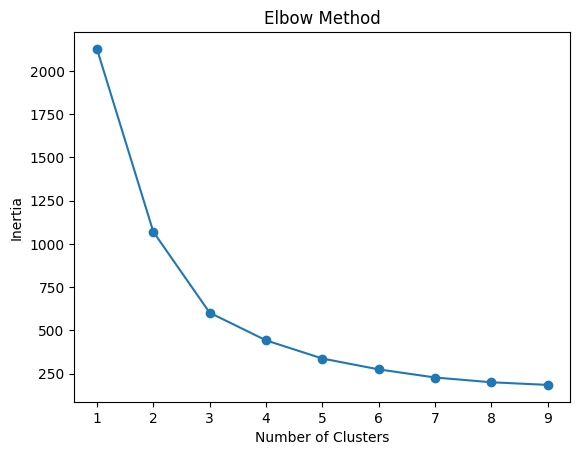

In [6]:
inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [7]:
k = 3  # adjust based on elbow plot

kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

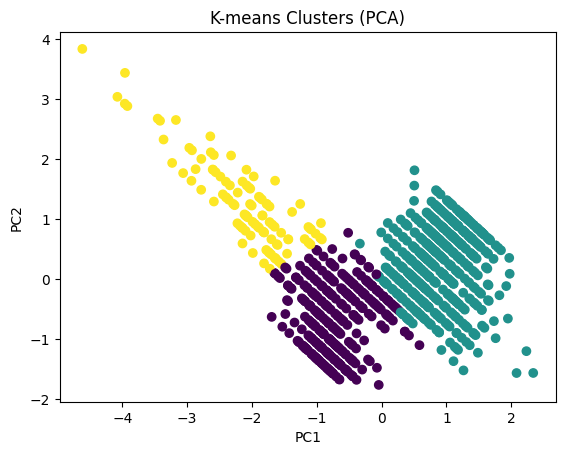

In [8]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)
plt.title("K-means Clusters (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [9]:
if text_column:
    vectorizer = TfidfVectorizer(stop_words='english')
    X_text = vectorizer.fit_transform(df[text_column])

    print("Text feature shape:", X_text.shape)

In [10]:
if text_column:
    from scipy.sparse import hstack
    
    # Combine numeric + text features
    X_combined = hstack([X_scaled, X_text])

    kmeans_combined = KMeans(n_clusters=3, random_state=42)
    df['Combined_Cluster'] = kmeans_combined.fit_predict(X_combined.toarray())